[np.float64(1.000000000000018), np.float64(514.9184559268051)]
Min and max eigenvalues of A :  None
Result summary -----------------
Optimal centralised alpha =  [-0.4312858  -0.64431775  0.06989261 -0.32290507  0.91200764  0.38417451
 -0.42481936  0.69767254  1.14370679 -0.62633655]


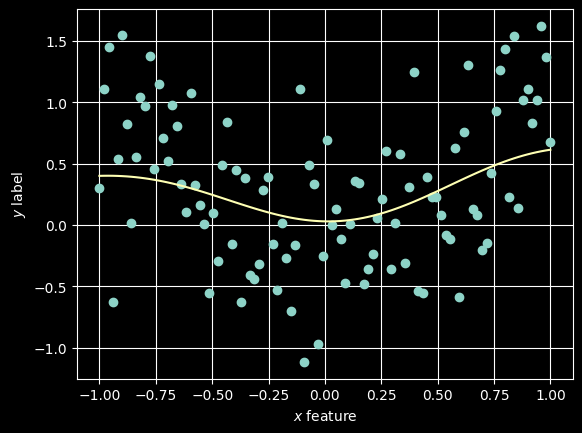

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from utils.dgd import DGD_cst_stepsize, get_best_L, DGD_vanishing_stepsize
from utils.essentials import *
from centralized_solution import Cov2, solve2, solve
import centralized_solution
from utils.plots import *
from utils.gradient_tracking import gradient_tracking

# First Part: Distributed Optimization Methods

We implement the following methods for the **first database**:

1. **DGD** – Distributed Gradient Descent  
   Simple multi-agent gradient descent algorithm.

2. **Gradient Tracking**  
   Extension of DGD that tracks gradient changes to improve convergence.

3. **ADMM** – Alternating Direction Method of Multipliers  
   Decomposes a global problem into smaller subproblems with local updates and consensus.

4. **Dual Decomposition**  
   Solves optimization problems by decomposing the dual function across agents.

In [2]:
with open("first_database.pkl", "rb") as f:
    x, y = pickle.load(f)
print(type(x), x.shape)
print(type(y))

<class 'numpy.ndarray'> (1000000,)
<class 'numpy.ndarray'>


/var/folders/1v/_q53htts55dbtnw1493wscjc0000gn/T/ipykernel_27930/2161377594.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x, y = pickle.load(f)


(1000000,) (1000000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


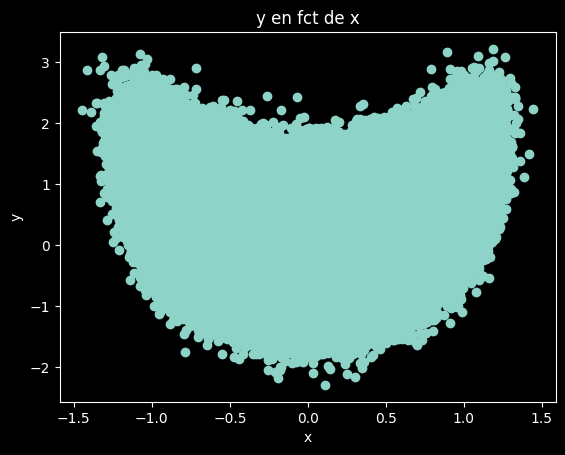

In [3]:
print(x.shape, y.shape)
print(type(x))
print(type(y))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y en fct de x")
plt.show()

### Starting with 5 agents and n = 100 data points

In [4]:
# Defining different graph topologies
# 5 agents
# Line graph: 
A_line = np.array([
    [0,1,0,0,0],
    [1,0,1,0,0],
    [0,1,0,1,0],
    [0,0,1,0,1],
    [0,0,0,1,0]
])

# Ring graph
A_ring = np.array([
    [0,1,0,0,1],
    [1,0,1,0,0],
    [0,1,0,1,0],
    [0,0,1,0,1],
    [1,0,0,1,0]
])

# Fully connected
A_full = np.ones((5,5)) - np.eye(5)

# Corresponding weight matrixs

W_line = build_mixing_matrix(A_line)
W_full = build_mixing_matrix(A_full)
W_ring = build_mixing_matrix(A_ring)

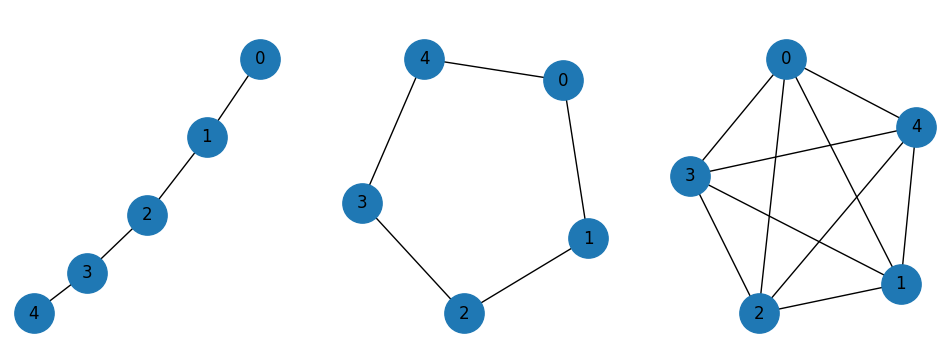

In [5]:
# Visualizing the graphs
import networkx as nx
G_line = nx.from_numpy_array(A_line)
G_ring = nx.from_numpy_array(A_ring)
G_full = nx.from_numpy_array(A_full)

graphs = [G_line, G_ring, G_full]
titles = ["Line Graph", "Ring Graph", "Fully Connected Graph"]

plt.figure(figsize=(12,4))

for i, (G, title) in enumerate(zip(graphs, titles), 1):
    plt.subplot(1,3,i)
    pos = nx.spring_layout(G, seed=42) 
    nx.draw(G, pos, with_labels=True, node_size=800, font_size=12)
    plt.title(title)

plt.show()

In [6]:
# Splitting n = 100 over 5 agents
n_data = 100
n_agents = 5
points_per_agent = n_data // n_agents # 20 per agent here

x_100 = x[:100]
y_100 = y[:100]

agents_x = [x_100[i*20: (i+1)*20] for i in range(n_agents)]
agents_y = [y_100[i*20: (i+1)*20] for i in range(n_agents)]

In [7]:
m = 10
sel = [i for i in range(n_data)]
ind = np.random.choice(sel, m, replace=False)
x_m = [x[i] for i in ind]

In [8]:
alpha_star, ind= solve2(x_100,y_100, x_m)
print(alpha_star)
print(len(alpha_star))

[np.float64(1.0000000000007176), np.float64(383.578211111853)]
Min and max eigenvalues of A :  None
[ 0.92770963  0.69506389 -0.5605466   0.64133534 -0.25052084 -0.93720576
  0.25721809 -0.08328176  0.34652485  0.00094716]
10


## Results for DGD with Constant Stepsize

In [9]:
# decentralized gradient descent
L = get_best_L(agents_x, x_m)

# alphas and gaps for different graph topologies
alphas_line, gaps_line = DGD_cst_stepsize(x_m, agents_x, W_line, agents_y, alpha_star, n_iter = 1000, sigma = 0.5, nu = 1.0, eta = 1/L)

alphas_ring, gaps_ring = DGD_cst_stepsize(x_m, agents_x, W_ring, agents_y, alpha_star, n_iter = 1000, sigma = 0.5, nu = 1.0, eta = 1/L)

alphas_full, gaps_full = DGD_cst_stepsize(x_m, agents_x, W_full, agents_y, alpha_star, n_iter = 1000, sigma = 0.5, nu = 1.0, eta = 1/L)
print(alphas_line[-1])

[array([ 0.63563732,  0.46289486, -0.31651832,  0.42710046, -0.16267601,
       -0.60800806,  0.21184097, -0.0065168 ,  0.23116926,  0.04769982]), array([ 0.5966524 ,  0.46225836, -0.35064139,  0.42619793, -0.16867672,
       -0.61975679,  0.17399722, -0.04315023,  0.2287426 ,  0.0107266 ]), array([ 0.58066525,  0.46843085, -0.3615139 ,  0.43225874, -0.16495497,
       -0.61872357,  0.1599438 , -0.05600686,  0.23412851, -0.00244061]), array([ 0.57512302,  0.48178141, -0.36140967,  0.44559095, -0.15276141,
       -0.60839291,  0.15673556, -0.05791923,  0.24723658, -0.00468227]), array([ 5.75820994e-01,  5.12413590e-01, -3.53272650e-01,  4.76338674e-01,
       -1.22729056e-01, -5.81731048e-01,  1.60334375e-01, -5.26144975e-02,
        2.78228603e-01,  1.81253662e-04])]


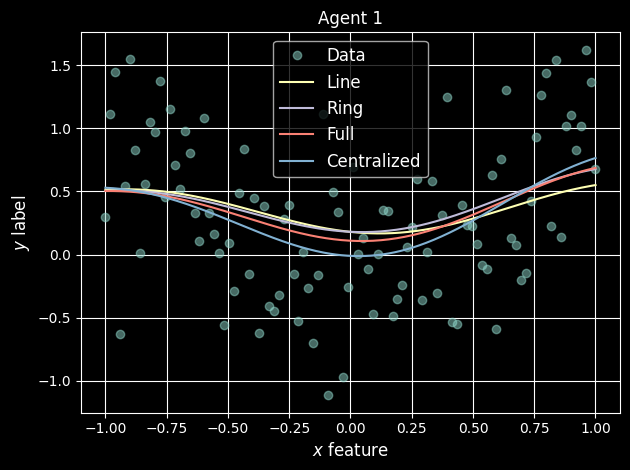

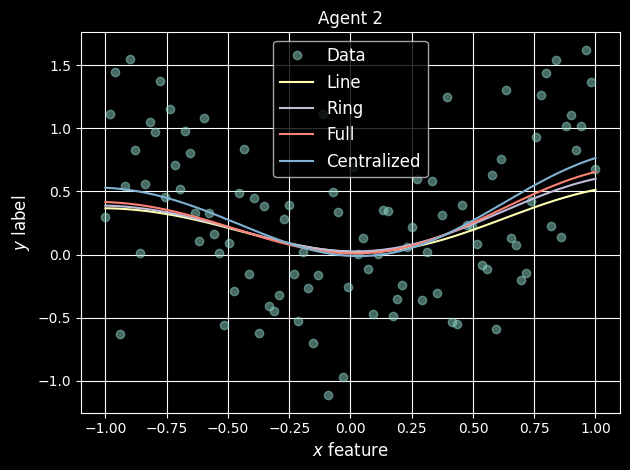

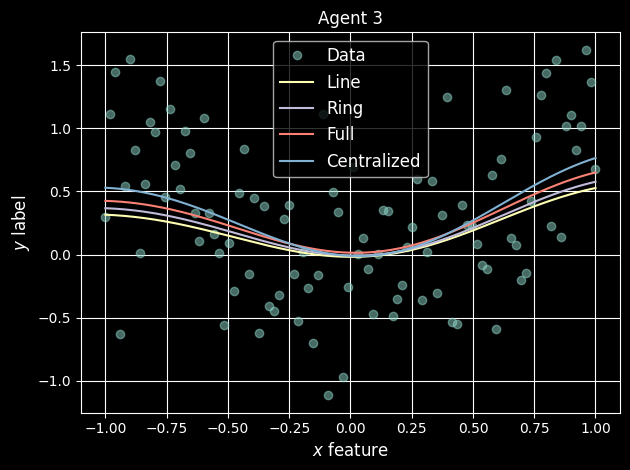

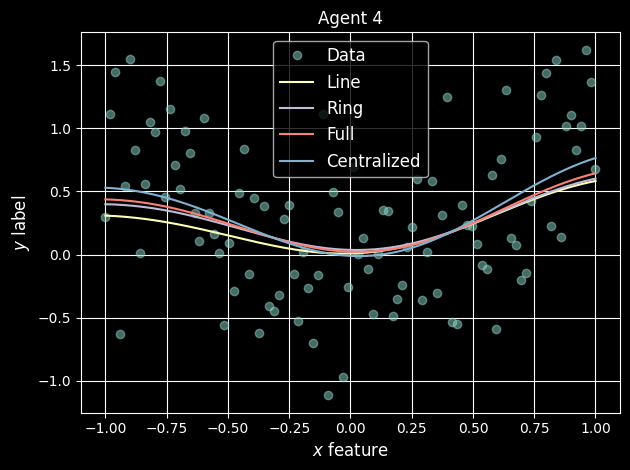

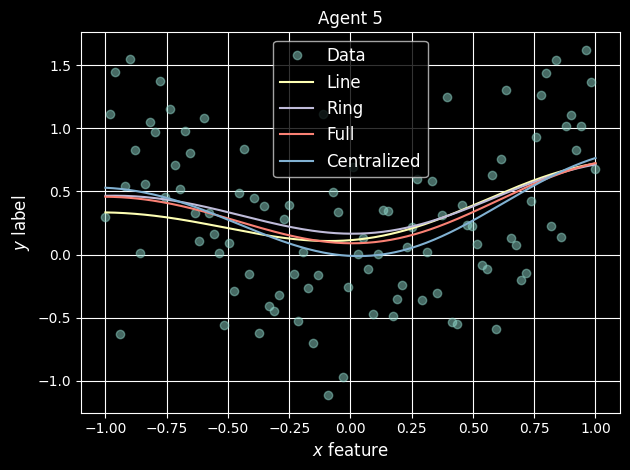

In [10]:
# Different topographies
alphas_dict = {
    'Line': alphas_line[-1],
    'Ring': alphas_ring[-1],
    'Full': alphas_full[-1],
    'Centralized': [alpha_star] * n_agents 
}

for i in range(n_agents):
    plot_fit_comparison(x_100, y_100, alphas_dict, x_m, agent_idx=i, folder = "DGD_constant_stepsize", filename = f'kernel_fit_agent_{i+1}.pdf' , Cov2= Cov2)

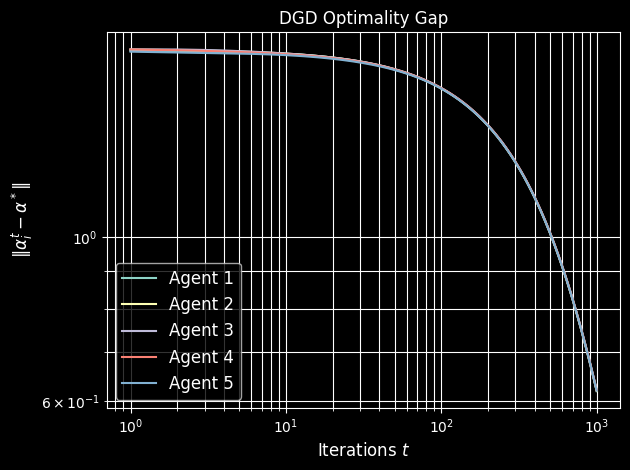

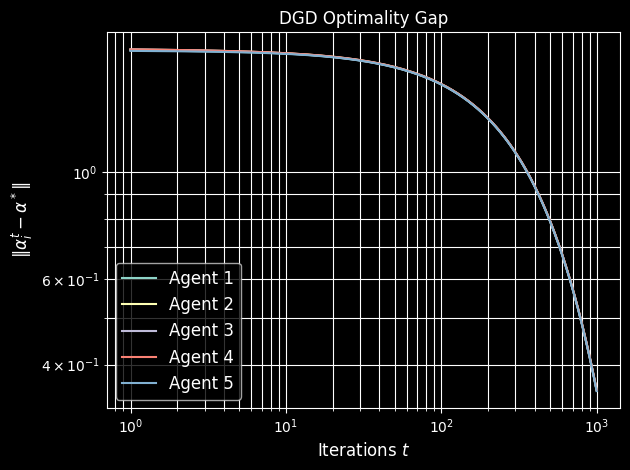

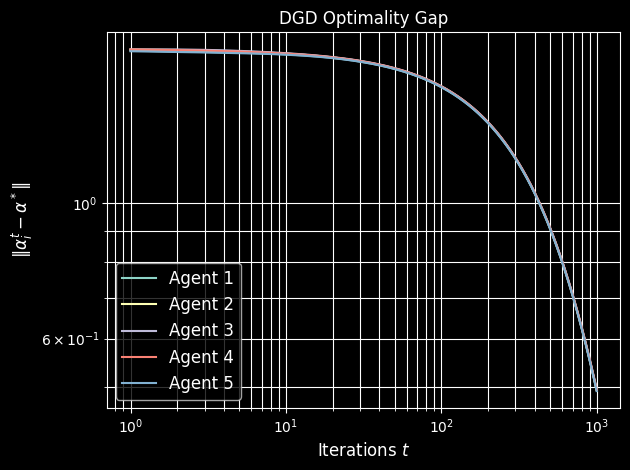

In [11]:
plot_gap(gaps_line, folder = "DGD_constant_stepsize", filename="gaps for a line graph")
plot_gap(gaps_full, folder = "DGD_constant_stepsize", filename="gaps for a full graph")
plot_gap(gaps_ring, folder = "DGD_constant_stepsize", filename="gaps for a ring graph")

## Results for DGD with vanishing stepsize
The step size is defined as
$$
\eta_t = \frac{1}{t^2}, \quad t = 1,2,\dots,n_{\text{iter}}.
$$

In [12]:
# alphas and gaps for different graph topologies
alphas_line, gaps_line = DGD_vanishing_stepsize(x_m, agents_x, W_line, agents_y, alpha_star, n_iter = 1000, sigma = 0.5, nu = 1.0)

alphas_ring, gaps_ring = DGD_vanishing_stepsize(x_m, agents_x, W_ring, agents_y, alpha_star, n_iter = 1000, sigma = 0.5, nu = 1.0)

alphas_full, gaps_full = DGD_vanishing_stepsize(x_m, agents_x, W_full, agents_y, alpha_star, n_iter = 1000, sigma = 0.5, nu = 1.0)
print(alphas_line[-1])

[array([ 0.33525054,  0.2980961 , -0.1473296 ,  0.27247622, -0.08338597,
       -0.29275506,  0.10234593, -0.00519321,  0.14191765,  0.0208666 ]), array([ 0.33522641,  0.29809629, -0.14735078,  0.27247624, -0.08338926,
       -0.2927621 ,  0.10232247, -0.00521593,  0.14191669,  0.02084368]), array([ 0.3352125 ,  0.29810037, -0.14736216,  0.27248019, -0.08338789,
       -0.29276358,  0.10230934, -0.00522846,  0.14191988,  0.02083098]), array([ 0.33520934,  0.29811253, -0.14736061,  0.27249239, -0.08337602,
       -0.29275304,  0.10230809, -0.00522862,  0.14193215,  0.02083054]), array([ 0.33521017,  0.29813409, -0.14735435,  0.27251406, -0.08335449,
       -0.29273367,  0.10231104, -0.00522443,  0.14195412,  0.02083441])]


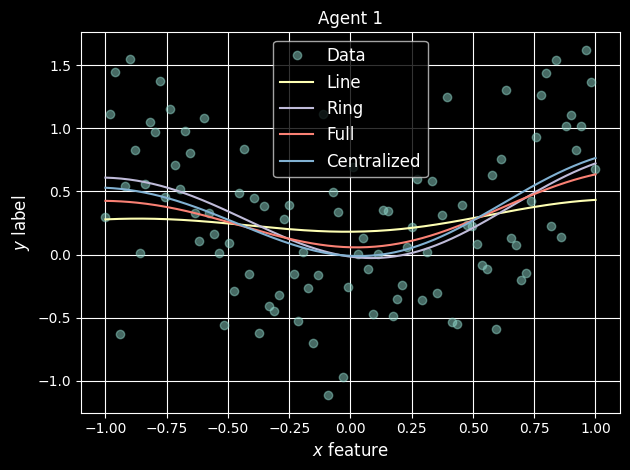

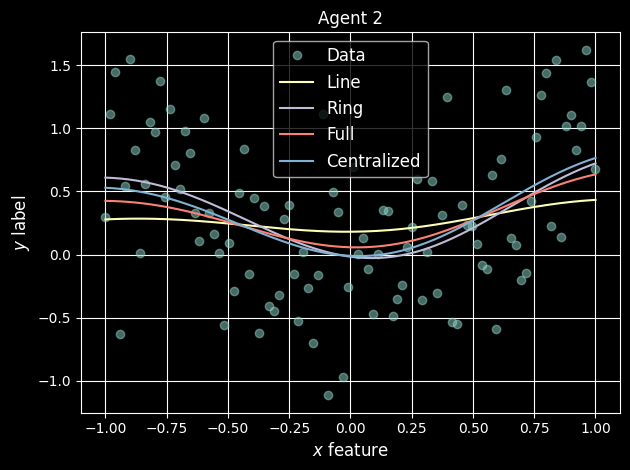

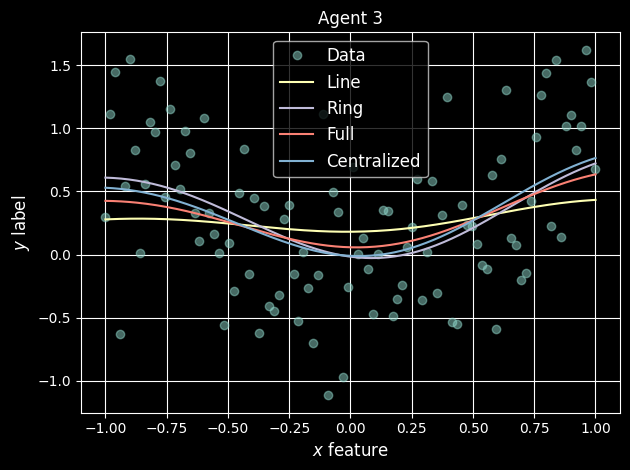

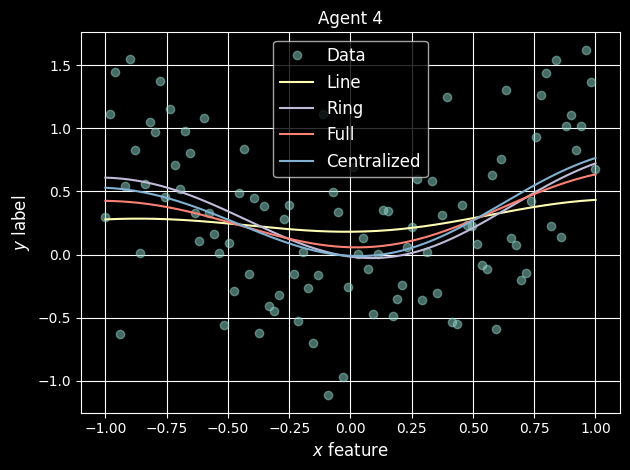

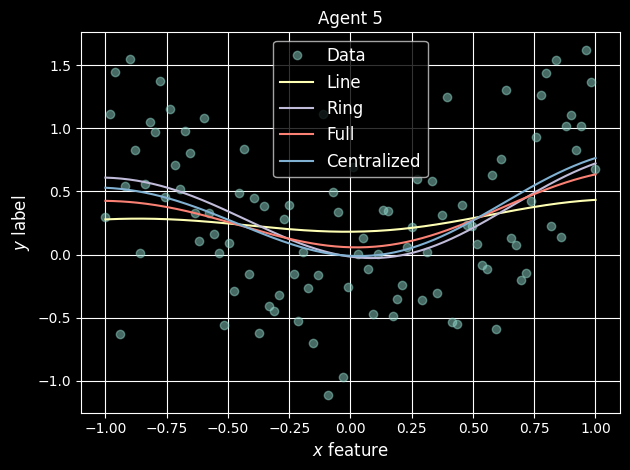

In [13]:
# Different topographies
alphas_dict = {
    'Line': alphas_line[-1],
    'Ring': alphas_ring[-1],
    'Full': alphas_full[-1],
    'Centralized': [alpha_star] * n_agents 
}

for i in range(n_agents):
    plot_fit_comparison(x_100, y_100, alphas_dict, x_m, agent_idx=i, folder = "DGD_vanishing_stepsize", filename = f'kernel_fit_agent_{i+1}.pdf' , Cov2= Cov2)

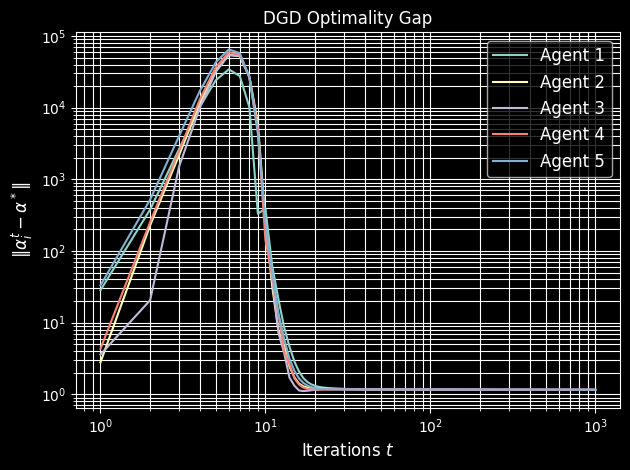

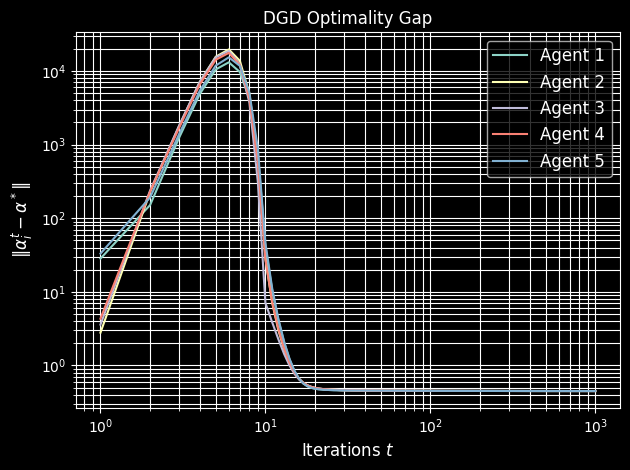

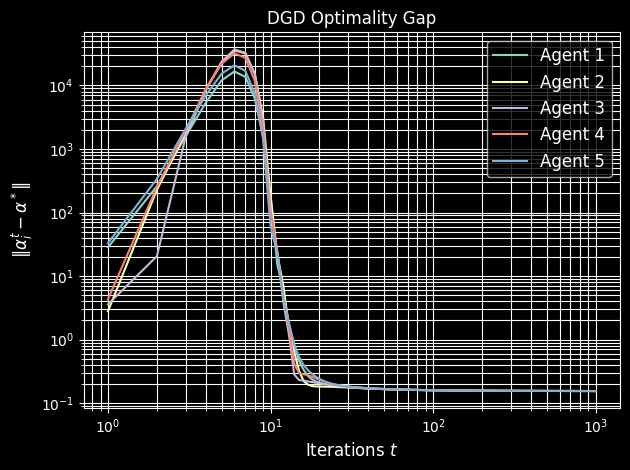

In [14]:
# Plotting gaps
plot_gap(gaps_line, folder = "DGD_vanishing_stepsize", filename="gaps for a line graph")
plot_gap(gaps_full, folder = "DGD_vanishing_stepsize", filename="gaps for a full graph")
plot_gap(gaps_ring, folder = "DGD_vanishing_stepsize", filename="gaps for a ring graph")

## Gradient Tracking

In [20]:
alphas_line, gaps_line, _ = gradient_tracking(x_m, agents_x, W_line, agents_y, alpha_star, n_iter = 100, sigma = 0.5, nu = 1.0, eta = 0.01)

alphas_ring, gaps_ring, _ = gradient_tracking(x_m, agents_x, W_ring, agents_y, alpha_star, n_iter = 100, sigma = 0.5, nu = 1.0, eta = 0.01)

alphas_full, gaps_full, _ = gradient_tracking(x_m, agents_x, W_full, agents_y, alpha_star, n_iter = 100, sigma = 0.5, nu = 1.0, eta = 0.01)

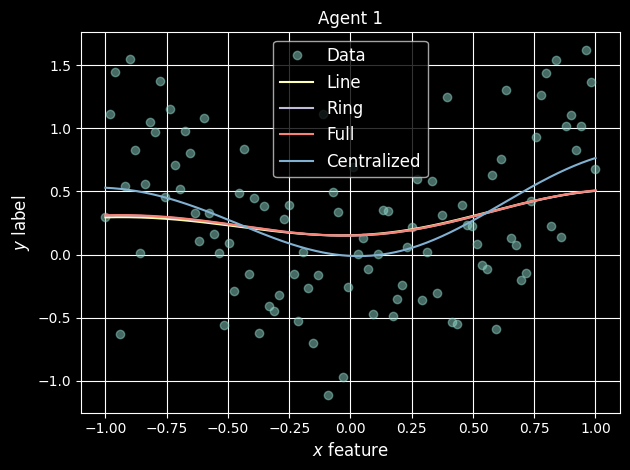

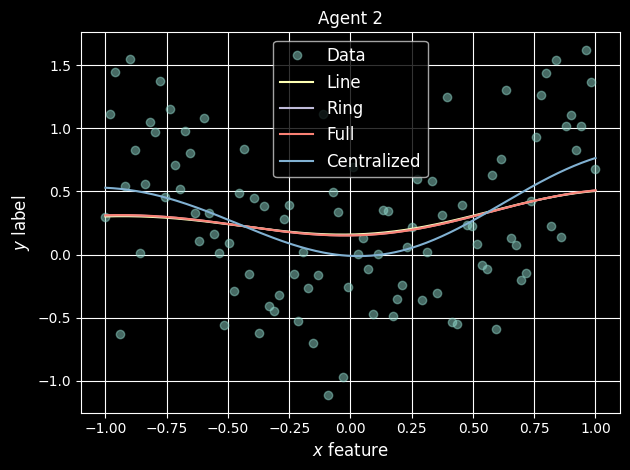

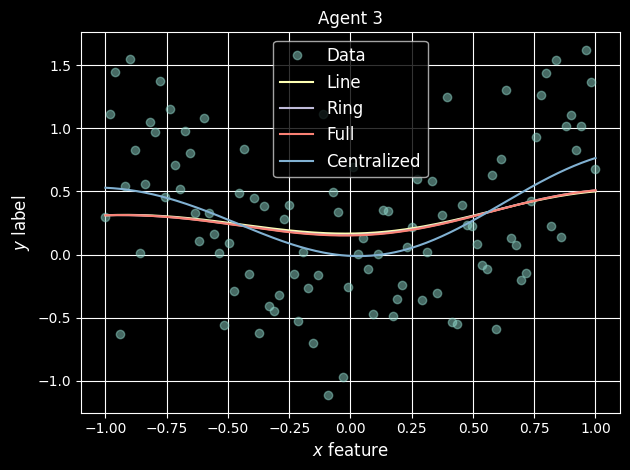

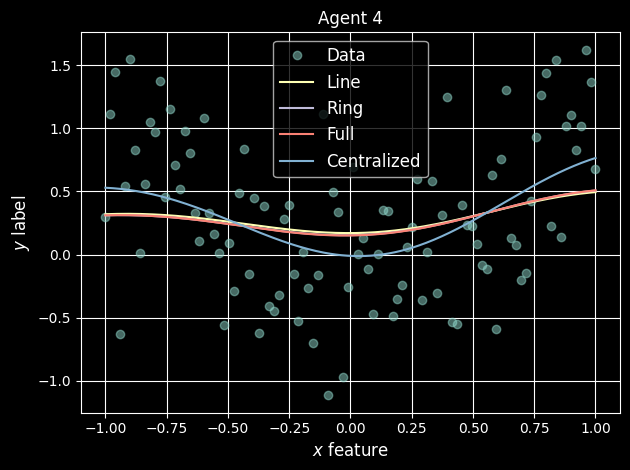

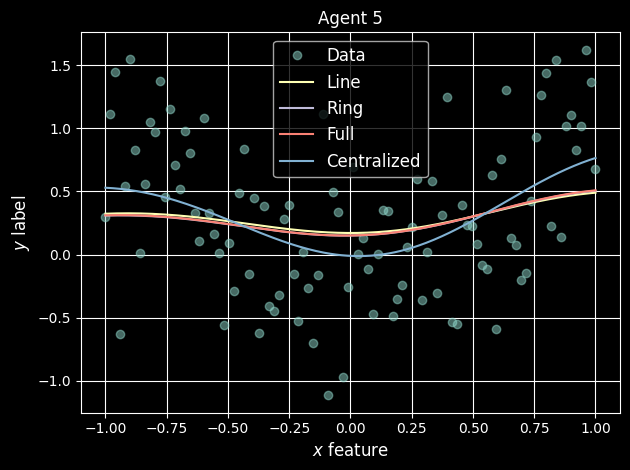

In [21]:
# Different topographies
alphas_dict = {
    'Line': alphas_line[-1],
    'Ring': alphas_ring[-1],
    'Full': alphas_full[-1],
    'Centralized': [alpha_star] * n_agents 
}

for i in range(n_agents):
    plot_fit_comparison(x_100, y_100, alphas_dict, x_m, agent_idx=i, folder = "Gradient-tracking", filename = f'kernel_fit_agent_{i+1}.pdf' , Cov2= Cov2)

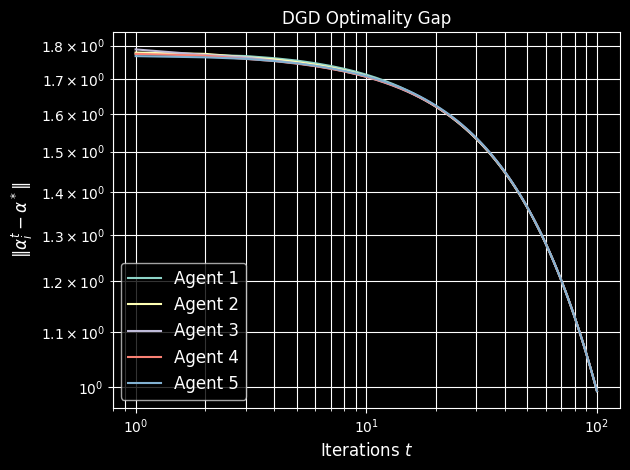

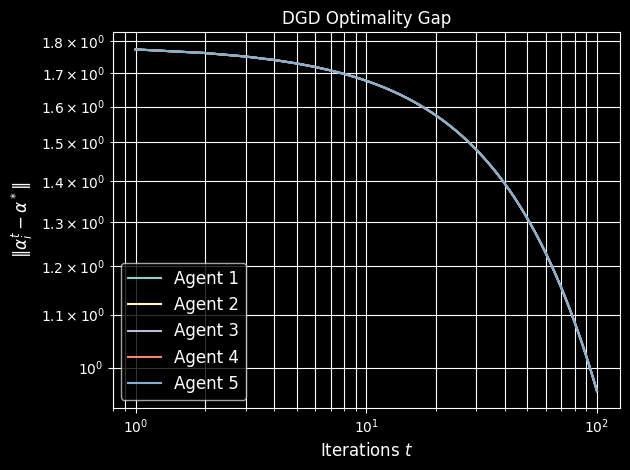

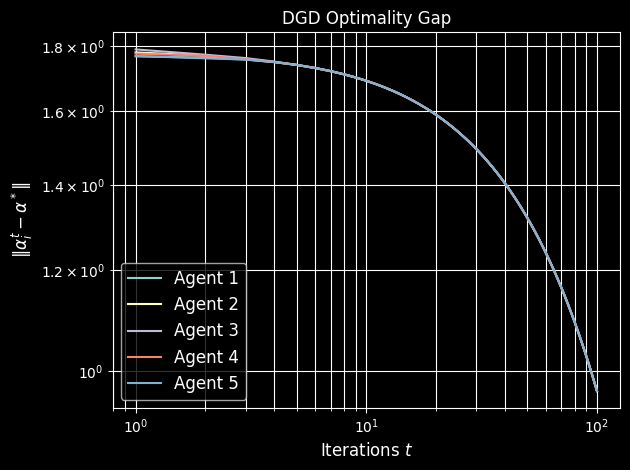

In [22]:
# Plotting gaps
plot_gap(gaps_line, folder = "Gradient-tracking", filename="gaps for a line graph")
plot_gap(gaps_full, folder = "Gradient-tracking", filename="gaps for a full graph")
plot_gap(gaps_ring, folder = "Gradient-tracking", filename="gaps for a ring graph")